# Домашнее задание 2. Регуляризация и контроль сложности моделей

## Структура домашней работы

Домашнее задание состоит из 9 задач, разделенных на три уровня сложности:

| Уровень | Задачи | Баллы (рекомендуемо) |
|---------|--------|----------------------|
| **Простые** | 1–4 | 3 (0.75 за задачу) |
| **Средние** | 5–7 | 4 (1 за задачу) |
| **Сложные** | 8, 9 | 4 (2 за задачу) |

**Итого:** 10 баллов


## Настройка окружения

In [1]:
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

# ----------------------------
# Общие настройки
# ----------------------------
SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ----------------------------
# Вспомогательные функции
# ----------------------------
def make_synthetic_linear_regression(
    n: int = 600,
    d: int = 20,
    noise_std: float = 0.5,
    sparsity: float = 0.5,
):
    """Синтетическая линейная регрессия: y = X w_true + noise.
    sparsity: доля нулевых компонент в w_true (примерно).
    """
    np.random.seed(42)
    X = np.random.randn(n, d).astype(np.float32)
    w_true = np.random.randn(d).astype(np.float32)
    # обнулим часть весов для наглядности (L1 должен это «любить»)
    k0 = int(d * sparsity)
    if k0 > 0:
        zero_idx = np.random.choice(d, size=k0, replace=False)
        w_true[zero_idx] = 0.0
    y = X @ w_true + noise_std * np.random.randn(n).astype(np.float32)
    return X, y, w_true

def train_val_test_split(X, y, train_ratio=0.6, val_ratio=0.2):
    n = len(X)
    np.random.seed(42)
    idx = np.random.permutation(n)
    n_train = int(n * train_ratio)
    n_val = int(n * val_ratio)
    train_idx = idx[:n_train]
    val_idx = idx[n_train:n_train+n_val]
    test_idx = idx[n_train+n_val:]
    return (X[train_idx], y[train_idx]), (X[val_idx], y[val_idx]), (X[test_idx], y[test_idx])

def mse(pred, target):
    return torch.mean((pred - target) ** 2)

def l2_norm(w: torch.Tensor) -> float:
    return float(torch.norm(w.detach(), p=2).cpu().item())

def sparsity_ratio(w: torch.Tensor, eps: float = 0.01) -> float:
    w_abs = torch.abs(w.detach()).cpu().numpy()
    return float(np.mean(w_abs < eps))

def to_tensor(x):
    return torch.tensor(x, dtype=torch.float32, device=device)

# Датасет для задач 2,3,4,5,6,7,9 (один и тот же)
X, y, w_true = make_synthetic_linear_regression(n=800, d=25, noise_std=0.7, sparsity=0.4)
(X_train, y_train), (X_val, y_val), (X_test, y_test) = train_val_test_split(X, y, 0.6, 0.2)

X_train, y_train = to_tensor(X_train), to_tensor(y_train).view(-1, 1)
X_val, y_val = to_tensor(X_val), to_tensor(y_val).view(-1, 1)
X_test, y_test = to_tensor(X_test), to_tensor(y_test).view(-1, 1)

w_true_t = to_tensor(w_true).view(-1, 1)

print("Shapes:", X_train.shape, y_train.shape, "| w_true:", w_true_t.shape)

Device: cpu
Shapes: torch.Size([480, 25]) torch.Size([480, 1]) | w_true: torch.Size([25, 1])


---

## Теоретический минимум

### Что такое регуляризация

**Регуляризация** — набор методов для уменьшения переобучения путем добавления ограничений на параметры.

$$\tilde{E}(\mathbf{w}) = E(\mathbf{w}) + \frac{\lambda}{2} \mathbf{w}^T\mathbf{w}$$

### L2-регуляризация (Weight Decay)

$$\Omega(\mathbf{w}) = \frac{\lambda}{2} ||\mathbf{w}||_2^2 = \frac{\lambda}{2} \sum_j w_j^2$$

Градиент: $\nabla \tilde{E}(\mathbf{w}) = \nabla E(\mathbf{w}) + \lambda \mathbf{w}$

### L1-регуляризация (Lasso)

$$\Omega(\mathbf{w}) = \frac{\lambda}{2} ||\mathbf{w}||_1 = \frac{\lambda}{2} \sum_j |w_j|$$

L1 приводит к **разреженным** решениям.

### Early Stopping

Прекращение обучения, когда значение loss на валидации начинает расти. Приблизительно: $\tau \eta \sim 1/\lambda$.

### Dropout

Случайное выключение нейронов с вероятностью $1-\rho$. При инференсе веса эффективно умножаются на $\rho$.

### Residual Connections

$$\mathbf{z}_l = F_l(\mathbf{z}_{l-1}) + \mathbf{z}_{l-1}$$

---

# ПРОСТЫЕ ЗАДАЧИ (1—4)

Эти задачи на понимание базовых концепций: L1-, L2-регуляризации, dropout, weight decay.

## Задача 1. L1- и L2-регуляризация вручную

### Постановка задачи

Реализуйте две функции, которые по вектору весов $w \in \mathbb{R}^d$ и коэффициенту регуляризации $\lambda$ вычисляют скалярные значения регуляризаторов:
- L1 (Lasso): $\Omega_{L1}(w) = \frac{\lambda}{2} \sum_j |w_j|$;
- L2 (Ridge): $\Omega_{L2}(w) = \frac{\lambda}{2} \sum_j w_j^2$.

Протестируйте функции на нескольких векторах весов, сравните с ручным счетом и прокомментируйте, как отличаются численные значения L1 и L2 для одного и того же $w$.

### Теоретический минимум
- Регуляризация добавляет к исходной функции ошибки $E(w)$ штраф: $\tilde{E}(w) = E(w) + \Omega(w)$.
- L2: $\Omega_{L2}(w) = \frac{\lambda}{2}\|w\|_2^2$, градиент по $w$: $\lambda w$.
- L1: $\Omega_{L1}(w) = \frac{\lambda}{2}\|w\|_1$, подградиент по $w_j$: $\lambda\,\text{sign}(w_j)$.
- L1 дает разреженные решения (многие веса точно 0), L2 — сглаживает веса, но почти не обнуляет.

### Этапы решения
1. Определите функцию `computel1_regularization(weights: torch.Tensor, lambdareg: float)` и реализуйте формулу L1: `lambdareg / 2 * torch.sum(torch.abs(weights))`.
2. Определите функцию `computel2_regularization(weights: torch.Tensor, lambdareg: float)` и реализуйте формулу L2: `lambdareg / 2 * torch.sum(weights ** 2)`.
3. Создайте несколько тестовых векторов `w` и значений `lambdareg`, посчитайте L1 и L2 и сравните с ручным расчетом.
4. Добавьте короткий комментарий: как меняется значение регуляризатора при увеличении $\lambda$ и нормы $w$.


In [6]:
# Задача 1. L1- и L2-регуляризация вручную

def compute_l1_regularization(w, lam: float):
    """Ω_L1(w) = (λ/2) * sum_j |w_j|"""
    assert "ваш код здесь"
    sigma_l1 = (lam / 2) * torch.sum(torch.abs(w))
    return sigma_l1

def compute_l2_regularization(w, lam: float):
    """Ω_L2(w) = (λ/2) * sum_j w_j^2"""
    assert "ваш код здесь"
    sigma_l2 = (lam / 2) * torch.sum(w ** 2)
    return sigma_l2

# Тесты
# lam - задайте значение лямбда
lam_lst = [0.5, 1, 1.5]

# tests = создайте список из трех тензоров (лучше сделать разными)
np.random.seed(42)
tests = [to_tensor(np.random.randn(3)) for _ in range(3)]

for lam in lam_lst:
    print(f'λ = {lam}')
# for w in tests: - итерируйтесь по списку тензоров, печатайте результаты
    for w in tests:
        print(f'Вектор w:{w.cpu().tolist()}')
        print(f'Норма вектора w:{l2_norm(w): .4f}')
        print(f'L1 ={compute_l1_regularization(w, lam): .4f}')
        print(f'L2 ={compute_l2_regularization(w, lam): .4f}')
    print('\n')

λ = 0.5
Вектор w:[0.49671414494514465, -0.13826429843902588, 0.6476885676383972]
Норма вектора w: 0.8279
L1 = 0.3207
L2 = 0.1713
Вектор w:[1.5230298042297363, -0.2341533750295639, -0.23413695394992828]
Норма вектора w: 1.5586
L1 = 0.4978
L2 = 0.6073
Вектор w:[1.5792127847671509, 0.7674347162246704, -0.4694743752479553]
Норма вектора w: 1.8175
L1 = 0.7040
L2 = 0.8258


λ = 1
Вектор w:[0.49671414494514465, -0.13826429843902588, 0.6476885676383972]
Норма вектора w: 0.8279
L1 = 0.6413
L2 = 0.3427
Вектор w:[1.5230298042297363, -0.2341533750295639, -0.23413695394992828]
Норма вектора w: 1.5586
L1 = 0.9957
L2 = 1.2146
Вектор w:[1.5792127847671509, 0.7674347162246704, -0.4694743752479553]
Норма вектора w: 1.8175
L1 = 1.4081
L2 = 1.6516


λ = 1.5
Вектор w:[0.49671414494514465, -0.13826429843902588, 0.6476885676383972]
Норма вектора w: 0.8279
L1 = 0.9620
L2 = 0.5140
Вектор w:[1.5230298042297363, -0.2341533750295639, -0.23413695394992828]
Норма вектора w: 1.5586
L1 = 1.4935
L2 = 1.8220
Вектор w:[

**Выводы**:  
1 L1 растёт линейно по |w|, L2 — квадратично.  
2 Соответственно, при наличии «больших» весов L2 штрафует сильнее, а L1 чаще приводит к разреженности (обнулению некоторых весов).  
3 Ручным расчётом были подтверждены полученные значения L1- и L2-терминов.

---

## Задача 2. Обучение с L2-регуляризацией

### Постановка задачи

Нужно обучить линейную модель регрессии на синтетическом датасете, добавив к функции потерь L2-регуляризацию. Требуется:
- реализовать обучение модели с различными значениями $\lambda$;
- визуализировать полученные веса (например, столбиковая диаграмма и/или сравнение с истинными весами);
- проанализировать, как величина $\lambda$ влияет на величины весов и качество (MSE на валидации/тесте).

### Теоретический минимум
- Линейная модель: $\hat{y} = Xw$.
- MSE: $E(w) = \frac{1}{N}\sum_i (\hat{y}_i - y_i)^2$.
- L2-регуляризованный loss: $\tilde{E}(w) = E(w) + \frac{\lambda}{2}\sum_j w_j^2$.
- Градиент: $\nabla_w \tilde{E} = \frac{2}{N} X^T(Xw - y) + \lambda w$.
- Увеличение $\lambda$ уменьшает норму весов, снижая variance и повышая bias.

### Этапы решения
1. Сгенерируйте данные `(X, y)` или воспользуйтесь готовой функцией генерации из ноутбука.
2. Реализуйте функцию обучения линейной модели с L2 (цикл по эпохам, MSE + L2-термин, backward, шаг оптимизатора).
3. Обучите модель для нескольких значений $\lambda$ (например, 0, 0.01, 0.1, 1.0) и сохраните итоговые веса.
4. Постройте графики весов для разных $\lambda$ и (при наличии) сравните с истинными весами.
5. Напишите краткий вывод о влиянии $\lambda$ на веса и качество.


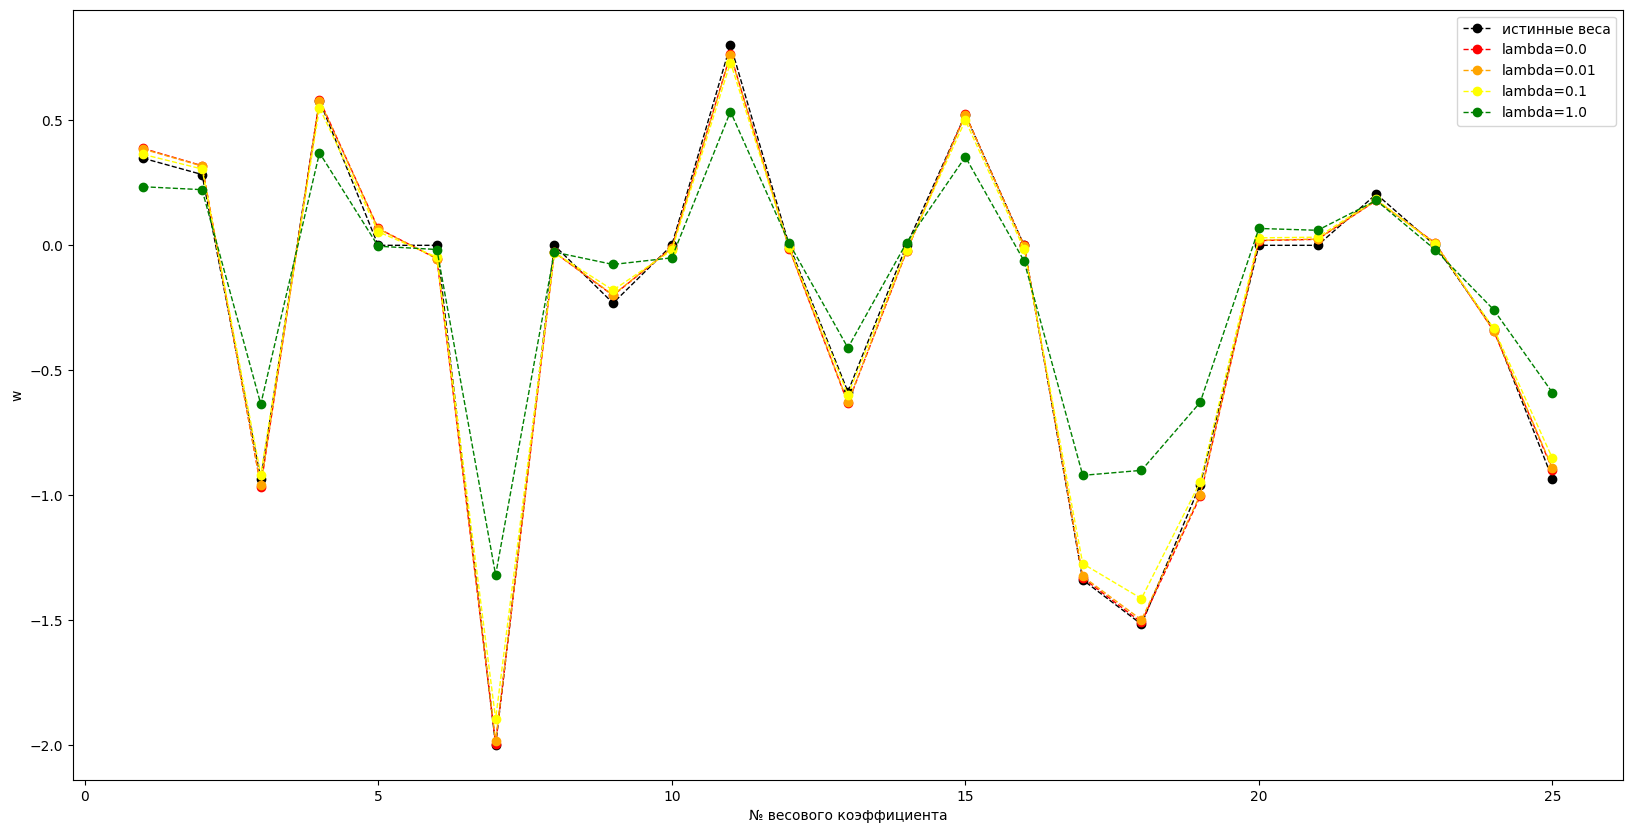

In [7]:
# Задача 2. Обучение с L2-регуляризацией (явно в loss)

class LinearRegressor(nn.Module):
    def __init__(self, d: int):
        assert "ваш код здесь"
        super().__init__()
        self.model_lin = nn.Linear(d, 1, bias = False)

    def forward(self, x):
        assert "ваш код здесь"
        return self.model_lin(x)

def reset_weights(mod):
    """
    Очистка весов модели
    """
    # Проверка наличия у слоя метода reset_parameters
    if hasattr(mod, 'reset_parameters'):
        mod.reset_parameters()

def train_linear_with_l2(
    X_train_t: torch.Tensor,
    y_train_t: torch.Tensor,
    X_val_t: torch.Tensor,
    y_val_t: torch.Tensor,
    X_test_t: torch.Tensor,
    y_test_t: torch.Tensor,
    lam: float,
    lr: float = 0.05,
    epochs: int = 500,
):
    assert "ваш код здесь"
    model = LinearRegressor(X_train_t.shape[1]).to(device)
    model.apply(reset_weights)
    optimizer = optim.SGD(model.parameters(), lr=lr)

    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model.train()
        optimizer.zero_grad()
        y_pred_train = model(X_train_t.to(device))
        model_weights = model.model_lin.weight.view(-1)
        loss = mse(y_pred_train.flatten(), y_train_t.flatten().to(device)) + compute_l2_regularization(model_weights, lam)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            train_losses.append(float(loss.item()))
            val_losses.append(float(mse(model(X_val_t.to(device)), y_val_t.to(device)).item()))

    with torch.no_grad():
        test_loss = float(mse(model(X_test_t.to(device)), y_test_t.to(device)).item())
        w_hat = model.model_lin.weight.detach().view(-1, 1).clone()

    return model, w_hat, train_losses, val_losses, test_loss


lambdas = [0.0, 0.01, 0.1, 1.0]
results = {}
for lam in lambdas:
    _, results[lam], _, _, _ = train_linear_with_l2(
        X_train, y_train, X_val, y_val, X_test, y_test,
        lam, lr=0.05, epochs=400
    )

# Визуализируем веса для разных λ и сравним с истинными
plt.figure(figsize=(20, 10))
#  ваш код здесь
w_num_lst = list(range(1, len(w_true)+1))
colors = ['red', 'orange', 'yellow', 'green']

plt.plot(
    w_num_lst, w_true,
    linestyle='--', marker='o', linewidth=1,
    color='black', label = 'истинные веса'
)

for i, pair in enumerate(results.items()):
    w_hat_np = pair[1].detach().cpu().numpy().flatten()
    plt.plot(
        w_num_lst, w_hat_np,
        linestyle='--', marker='o', linewidth=1,
        label=f'lambda={pair[0]}',color=colors[i]
)

plt.xlabel("№ весового коэффициента"); plt.ylabel("w")
plt.legend()
plt.show()

**Выводы:**  
1 Весовые коэффициенты, расчитанные при различных значениях $\lambda$ имеют значения, близкие к истинным.  
2 Из построенного графика следует, что на принятом диапазоне $\lambda$ точность определения весовых коэффициентов не чувствительна к значениям $\lambda$.

---

## Задача 3. Weight Decay в оптимизаторе PyTorch

### Постановка задачи

Перепишите обучение из задачи 2, используя встроенный параметр `weight_decay` у оптимизатора PyTorch вместо явного добавления L2 в loss. Сравните результаты (веса и метрики) с задачей 2 и убедитесь, что поведение совпадает при одинаковом $\lambda$.

### Теоретический минимум
- В PyTorch L2-регуляризация обычно задается через `weight_decay` в оптимизаторе.
- При `weight_decay = λ` оптимизатор добавляет $\lambda w$ к градиенту параметров, что эквивалентно L2 в функции потерь.
- Нельзя одновременно применять один и тот же L2 и в loss, и в `weight_decay` для тех же параметров (иначе будет двойной штраф).

### Этапы решения
1. Постройте линейную модель, как в задаче 2.
2. Создайте оптимизатор: `optim.SGD(model.parameters(), lr=..., weight_decay=lambda_value)`.
3. Напишите цикл обучения, где loss = MSE без явного L2-термина.
4. Обучите для нескольких `lambda_value` и сохраните веса/метрики.
5. Сравните с результатами задачи 2 и сделайте вывод.


In [8]:
# Задача 3. Weight Decay в оптимизаторе PyTorch

def train_linear_with_weight_decay(
    X_train_t: torch.Tensor,
    y_train_t: torch.Tensor,
    X_val_t: torch.Tensor,
    y_val_t: torch.Tensor,
    X_test_t: torch.Tensor,
    y_test_t: torch.Tensor,
    weight_decay: float,
    lr: float = 0.05,
    epochs: int = 600,
):
    model = LinearRegressor(X_train_t.shape[1]).to(device)
    model.apply(reset_weights)
    opt = optim.SGD(model.parameters(), lr=lr, weight_decay=weight_decay)

    train_losses, val_losses = [], []
    for _ in range(epochs):
        model.train()
        opt.zero_grad()

        pred = model(X_train_t.to(device))
        loss = mse(pred, y_train_t.to(device))  # без явного L2

        loss.backward()
        opt.step()

        model.eval()
        with torch.no_grad():
            train_losses.append(float(loss.item()))
            val_losses.append(float(mse(model(X_val_t.to(device)), y_val_t.to(device)).item()))

    with torch.no_grad():
        test_loss = float(mse(model(X_test_t.to(device)), y_test_t.to(device)).item())
        w_hat = model.model_lin.weight.detach().view(-1, 1).clone()
    return model, w_hat, train_losses, val_losses, test_loss


# Сравнение: явный L2 (из задачи 2) vs weight_decay
compare_lams = [0.0, 0.1, 1.0]
for lam in compare_lams:
    _, w_l2, _, _, test_l2 = train_linear_with_l2(
        X_train, y_train, X_val, y_val, X_test, y_test,
        lam, lr=0.05, epochs=400
    )
    _, w_wd, _, _, test_wd = train_linear_with_weight_decay(
        X_train, y_train, X_val, y_val, X_test, y_test,
        lam, lr=0.05, epochs=400
    )
    diff = float(torch.norm(w_l2 - w_wd).cpu().item())
    print(f"λ={lam:<3} | test_mse L2={test_l2:.4f} | test_mse WD={test_wd:.4f} | ||w_L2 - w_WD||2={diff:.4f}")

λ=0.0 | test_mse L2=0.4609 | test_mse WD=0.4609 | ||w_L2 - w_WD||2=0.0000
λ=0.1 | test_mse L2=0.5241 | test_mse WD=0.5241 | ||w_L2 - w_WD||2=0.0000
λ=1.0 | test_mse L2=2.0863 | test_mse WD=2.0863 | ||w_L2 - w_WD||2=0.0000


**Выводы:**  
1 Для всех рассмотренных значений $\lambda$, кроме нулевого, наблюдаются отличные от нуля значения норм разностей векторов весов моделей, в которых L2-регуляризация выполнялась различными способами.    
2 По метрике MSE на тестовой выборке модель, в которую при обучении передавался параметр weight_decay, показывает близкую или меньшую точность.

---

## Задача 4. Early Stopping

### Постановка задачи

Реализуйте механизм ранней остановки (Early Stopping), который:
- отслеживает метрику (например, `val_loss`) по эпохам;
- прекращает обучение, если метрика не улучшается более чем на `min_delta` в течение `patience` эпох;
- сохраняет лучшие веса модели (по минимальному `val_loss`).

Интегрируйте этот механизм в цикл обучения одной из моделей из предыдущих задач.

### Теоретический минимум
- Early Stopping — форма регуляризации: вместо явного штрафа на веса ограничивается эффективное время обучения.
- Идея: после некоторой эпохи модель начинает переобучаться, и `val_loss` растет.
- Параметры:
  - `patience` — сколько эпох ждать улучшения;
  - `min_delta` — минимальное изменение loss, считаемое улучшением.

### Этапы решения
1. Реализуйте класс `EarlyStopping` с полями `best_loss`, `patience`, `min_delta`, `counter`, `best_state`.
2. В методе `__call__(val_loss)`:
   - если `val_loss < best_loss - min_delta`: обновить `best_loss`, сохранить `best_state`, сбросить `counter`;
   - иначе: увеличить `counter`.
3. Если `counter >= patience`, вернуть флаг остановки.
4. В цикле обучения после каждой эпохи вызывайте `early_stopping(val_loss)` и прерывайте цикл при срабатывании.
5. После обучения загрузите `best_state` в модель и сравните кривые train/val loss с/без Early Stopping.


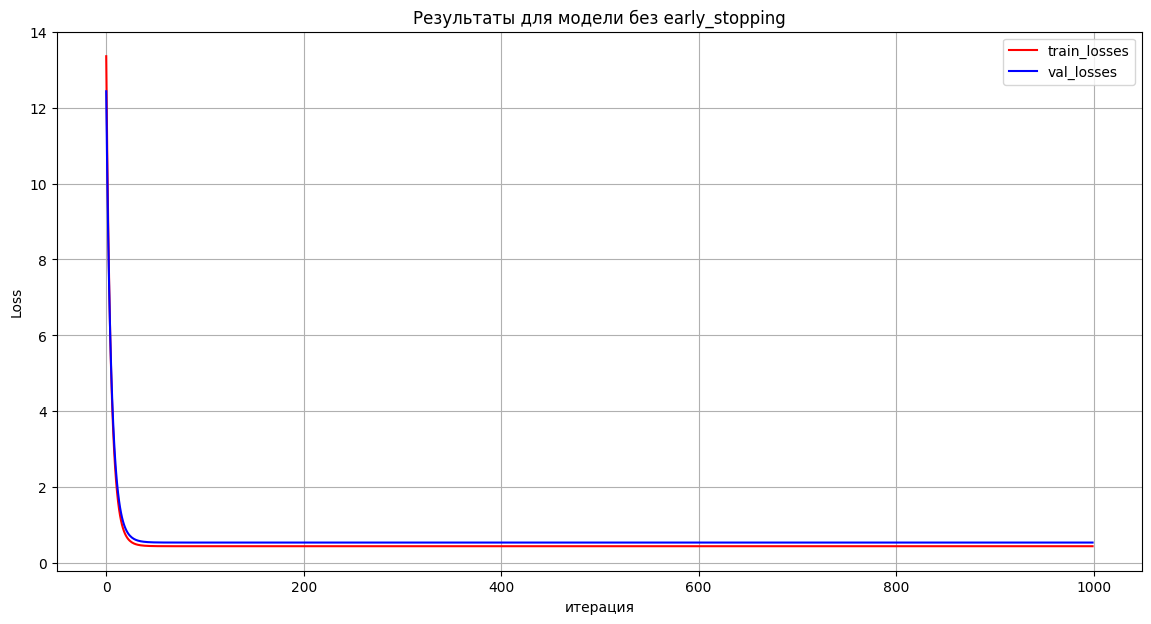

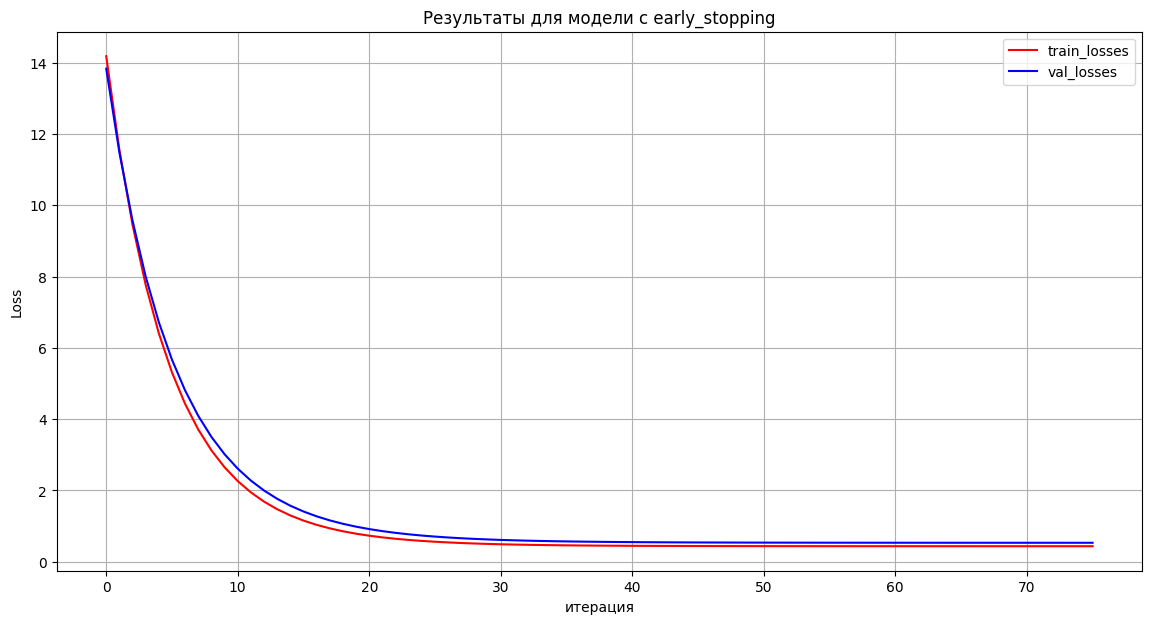

In [9]:
# Задача 4: ваш код здесь

class EarlyStopping:
    def __init__(self, model: nn.Module, patience: int = 5, min_delta: float = 1e-3):
        self.model = model
        self.patience = patience
        self.min_delta = min_delta
        self.best_loss = float('inf')
        self.counter = 0
        self.best_state = None
        self.stopped_epoch = None

    def __call__(self, val_loss: float):
        improved = val_loss < (self.best_loss - self.min_delta)
        if improved:
            self.best_loss = val_loss
            self.counter = 0
            # Обновление лучших весов
            self.best_state = {
                key: value.detach().clone() for key, value in self.model.state_dict().items()
            }
        else:
            self.counter += 1
            if self.counter >= self.patience:
                return True
        return False

    def early_stopping(self, val_loss: float):
        return self.__call__(val_loss)

def train_linear_with_early_stopping(
    X_train_t: torch.Tensor,
    y_train_t: torch.Tensor,
    X_val_t: torch.Tensor,
    y_val_t: torch.Tensor,
    X_test_t: torch.Tensor,
    y_test_t: torch.Tensor,
    lr: float = 0.05,
    max_epochs: int = 500,
    patience: int = 5,
    min_delta: float = 1e-3
    ):
    model = LinearRegressor(X_train_t.shape[1]).to(device)
    model.apply(reset_weights)
    optimizer = optim.SGD(model.parameters(), lr=lr)
    es = EarlyStopping(model=model, patience=patience, min_delta=min_delta)

    train_losses, val_losses = [], []
    for _ in range(max_epochs):
        model.train()
        optimizer.zero_grad()

        pred = model(X_train_t.to(device))
        loss = mse(pred, y_train_t.to(device))

        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            val_loss = float(mse(model(X_val_t.to(device)), y_val_t.to(device)).item())
            train_losses.append(float(loss.item()))
            val_losses.append(val_loss)

        if es.early_stopping(val_loss):
            break

    # Загрузка лучших весов в модель
    if es.best_state is not None:
        model.load_state_dict(es.best_state)

    with torch.no_grad():
        test_loss = float(mse(model(X_test_t.to(device)), y_test_t.to(device)).item())
        w_hat = model.model_lin.weight.detach().view(-1, 1).clone()
    return model, w_hat, train_losses, val_losses, test_loss


# Результаты для модели без early_stopping,
# т.е. когда max_epochs = patience
_, _, train_losses, val_losses, _ = train_linear_with_early_stopping(
    X_train, y_train, X_val, y_val, X_test, y_test,
    lr=0.05, max_epochs=1000, patience=1000, min_delta=1e-4
)

iterations = list(range(len(train_losses)))
plt.figure(figsize=(14, 7))
plt.plot(
    iterations, train_losses,
    color='red', label='train_losses'
)
plt.plot(
    iterations, val_losses,
    color='blue', label='val_losses'
)

plt.grid(True)
plt.legend()
plt.title("Результаты для модели без early_stopping")
plt.xlabel("итерация"); plt.ylabel("Loss")
plt.show()


# Результаты для модели с early_stopping,
_, _, train_losses, val_losses, _ = train_linear_with_early_stopping(
    X_train, y_train, X_val, y_val, X_test, y_test,
    lr=0.05, max_epochs=1000, patience=3, min_delta=1e-4
)

iterations = list(range(len(train_losses)))
plt.figure(figsize=(14, 7))
plt.plot(
    iterations, train_losses,
    color='red', label='train_losses'
)
plt.plot(
    iterations, val_losses,
    color='blue', label='val_losses'
)

plt.grid(True)
plt.legend()
plt.title("Результаты для модели с early_stopping")
plt.xlabel("итерация"); plt.ylabel("Loss")
plt.show()

**Выводы:**  
1 Из сравнения кривых потерь для обучающих и валидационных выборок моделей без ранней остановки и с ранней остановкой следует, что применение early_stopping позволяет существенно сократить требуемое число эпох обучения, в данном примере: с 1000 до порядка 60.  
2 Применение early_stopping,  как таковое, не обеспечивает повышения точности модели.  

---

---

# СРЕДНИЕ ЗАДАЧИ (5—7)

Эти задачи требуют комбинирования нескольких концепций и анализа.

---

## Задача 5. Сравнение L1- и L2-регуляризации

### Постановка задачи

Обучите две линейные модели на одном и том же датасете:
- одну с L1-регуляризацией (Lasso);
- другую с L2-регуляризацией (Ridge) при одинаковом $\lambda$ (например, 0.1).

Для обеих моделей сравните:
- качество (MSE на валидации/тесте),
- разреженность весов (долю компонент, для которых $|w_j| < 0.01$),
- норму $\|w\|_2$.

### Теоретический минимум
- L1: $\Omega_{L1}(w) = \frac{\lambda}{2}\sum_j |w_j|$ → обычно даёт sparse-веса.
- L2: $\Omega_{L2}(w) = \frac{\lambda}{2}\sum_j w_j^2$ → сжимает веса, но редко делает их строго нулевыми.
- Геометрически: L1-шар — ромб, L2-шар — круг; точка минимума чаще попадает на вершину ромба, «обнуляя» координату.

### Этапы решения
1. Разделите данные на train/val/test (или используйте уже готовые split-функции).
2. Обучите модель с L1-регуляризацией (добавьте L1-термин в loss и реализуйте обновление параметров).
3. Обучите модель с L2-регуляризацией при том же $\lambda$.
4. Для каждой модели вычислите:
   - `test_mse`,
   - `l2_norm = torch.norm(w)`,
   - `sparsity = (torch.abs(w) < 0.01).float().mean()`.
5. Оформите результаты в таблицу/график и сделайте вывод о различиях между L1 и L2.


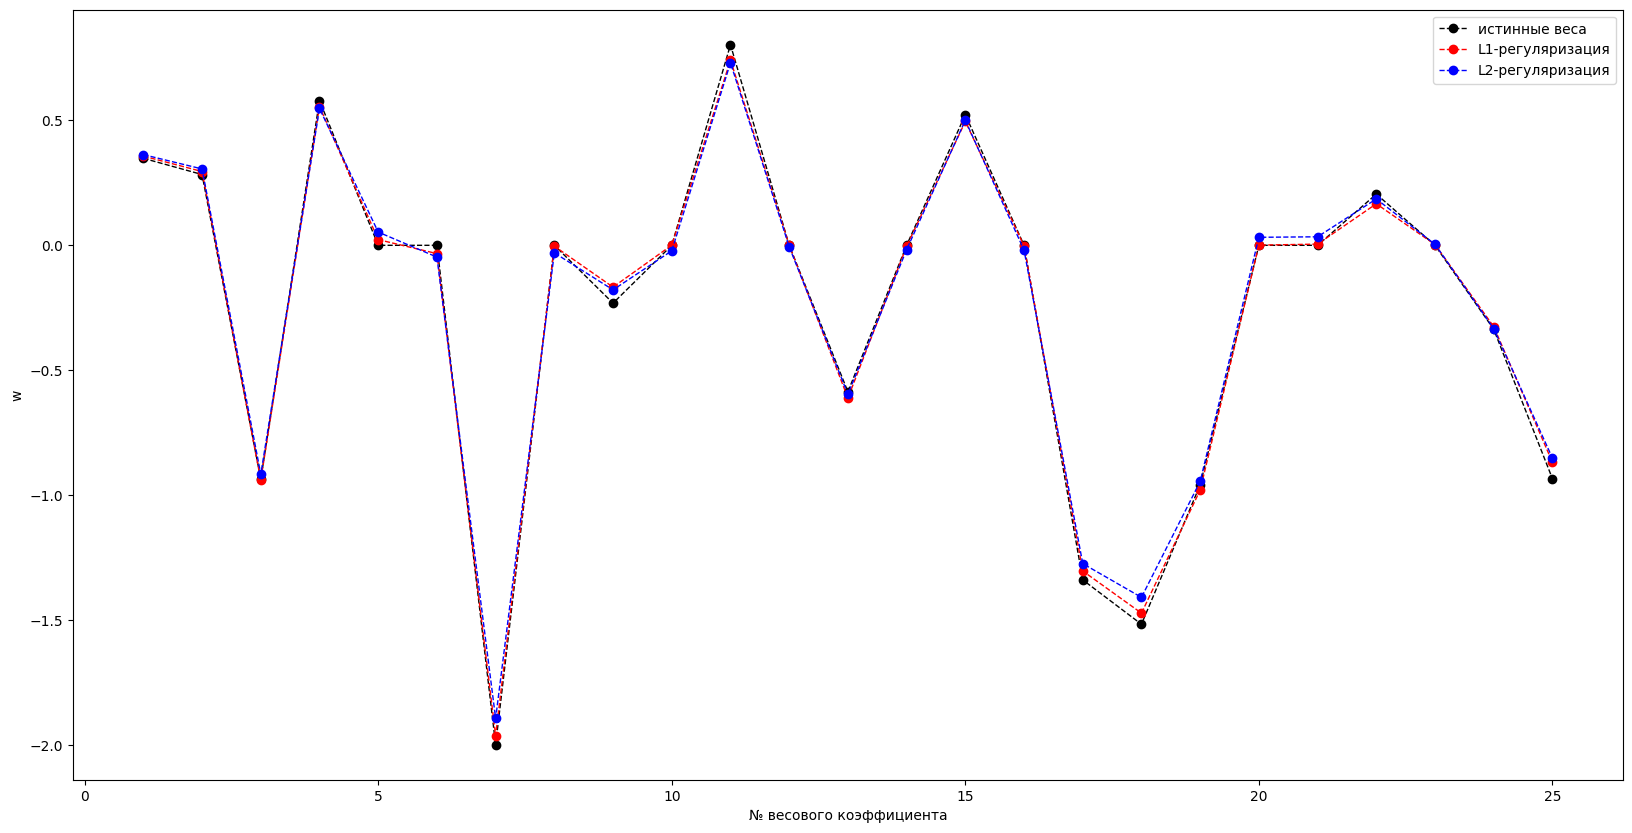

,Regularization,test_mse,l2_norm,sparsity
0,L1,0.494803,3.489147,0.32
1,L2,0.527408,3.392178,0.08


In [10]:
# Задача 5. Сравнение L1- и L2-регуляризации

def train_linear_with_l1(
    X_train_t: torch.Tensor,
    y_train_t: torch.Tensor,
    X_val_t: torch.Tensor,
    y_val_t: torch.Tensor,
    X_test_t: torch.Tensor,
    y_test_t: torch.Tensor,
    lam: float,
    lr: float = 0.05,
    epochs: int = 800,
):
    assert "ваш код здесь"
    model_L1 = LinearRegressor(X_train_t.shape[1]).to(device)
    model_L1.apply(reset_weights)
    optimizer = optim.SGD(model_L1.parameters(), lr=lr)

    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model_L1.train()
        optimizer.zero_grad()
        y_pred_train = model_L1(X_train_t.to(device))
        model_weights = model_L1.model_lin.weight.view(-1)
        loss = mse(y_pred_train.flatten(), y_train_t.flatten().to(device)) + compute_l1_regularization(model_weights, lam)
        loss.backward()
        optimizer.step()

        model_L1.eval()
        with torch.no_grad():
            train_losses.append(float(loss.item()))
            val_losses.append(float(mse(model_L1(X_val_t.to(device)), y_val_t.to(device)).item()))

    with torch.no_grad():
        test_loss = float(mse(model_L1(X_test_t.to(device)), y_test_t.to(device)).item())
        w_hat = model_L1.model_lin.weight.detach().view(-1, 1).clone()

    return model_L1, w_hat, train_losses, val_losses, test_loss



# попробуйте поэкспериментировать с разными параметрами лямбда
plt.figure(figsize=(20, 10))
w_num_lst = list(range(1, len(w_true)+1))
plt.plot(
    w_num_lst, w_true,
    linestyle='--', marker='o', linewidth=1,
    color='black', label = 'истинные веса'
)

result_dict = {
    'Regularization': ['L1', 'L2'],
    'test_mse': [],
    'l2_norm': [],
    'sparsity': []
}

lam = 0.1
_, w_l1, _, _, test_l1 = train_linear_with_l1(
    X_train, y_train, X_val, y_val, X_test, y_test,
    lam, lr=0.05, epochs=70
)
result_dict['test_mse'].append(test_l1)
result_dict['l2_norm'].append(float(torch.norm(w_l1).detach().item()))
result_dict['sparsity'].append((torch.abs(w_l1) < 0.01).float().mean().item())

plt.plot(
    w_num_lst, w_l1.detach().cpu().numpy().flatten(),
    linestyle='--', marker='o', linewidth=1,
    color='red', label = 'L1-регуляризация'
)

_, w_l2, _, _, test_l2 = train_linear_with_l2(
    X_train, y_train, X_val, y_val, X_test, y_test,
    lam, lr=0.05, epochs=70
)
result_dict['test_mse'].append(test_l2)
result_dict['l2_norm'].append(float(torch.norm(w_l2).detach().item()))
result_dict['sparsity'].append((torch.abs(w_l2) < 0.01).float().mean().item())

plt.plot(
    w_num_lst, w_l2.detach().cpu().numpy().flatten(),
    linestyle='--', marker='o', linewidth=1,
    color='blue', label = 'L2-регуляризация'
)

plt.xlabel("№ весового коэффициента"); plt.ylabel("w")
plt.legend()
plt.show()

# ваш код вывода L1 и L2 версий здесь

result_df = pd.DataFrame(result_dict)
display(result_df)

**Выводы:**  
1 Для вариантов с L1- и L2-регуляризацией получены близкие результаты.   
2 Результаты намерено выведены для малого числа эпох (70), т.к. при числе эпох более 100 результаты для моделей становятся неразличимыми.    
3 Схожие рузультаты при различных типах регуляризации могут объясняться простотой модели, состоящей из одного нейрона, т.к. ранее (в задании 2) изменение коэффициента регуляризации также не приводило к существенному изменению весов модели.

---

## Задача 6. Эксперимент с λ

### Постановка задачи

Исследуйте влияние коэффициента регуляризации $\lambda$ на качество L2-регуляризованной модели и величину весов. Необходимо:
- перебрать набор значений $\lambda$;
- обучить модель для каждого значения;
- собрать и визуализировать зависимости `val_loss` и $\|w\|_2$ от $\lambda$.

### Теоретический минимум
- При маленьком $\lambda$ модель почти без регуляризации → низкий bias, высокий variance (overfitting).
- При большом $\lambda$ веса сильно сжаты → высокий bias, низкий variance (underfitting).
- Оптимальное $\lambda$ обычно выбирают по минимуму val_loss.

### Этапы решения
1. Задайте список `lambdas = [0.0, 0.001, 0.01, 0.1, 1.0, 10.0]`.
2. Для каждого `lam` обучите модель с L2-регуляризацией (см. задачу 2) и сохраните `val_loss`, `test_loss`, `l2_norm` весов.
3. Постройте графики: `val_loss` vs `log10(lambda)` и `l2_norm` vs `log10(lambda)`.
4. Найдите значение `lambda`, при котором `val_loss` минимальна.
5. Сформулируйте вывод о наблюдаемом bias-variance tradeoff.


λ=0.0    | val MSE=0.5307 | ||w||2=3.570
λ=0.0001 | val MSE=0.5306 | ||w||2=3.569
λ=0.001  | val MSE=0.5309 | ||w||2=3.567
λ=0.01   | val MSE=0.5324 | ||w||2=3.551
λ=0.1    | val MSE=0.5794 | ||w||2=3.390
λ=1.0    | val MSE=2.3510 | ||w||2=2.343
λ=10.0   | val MSE=10.5937 | ||w||2=0.589


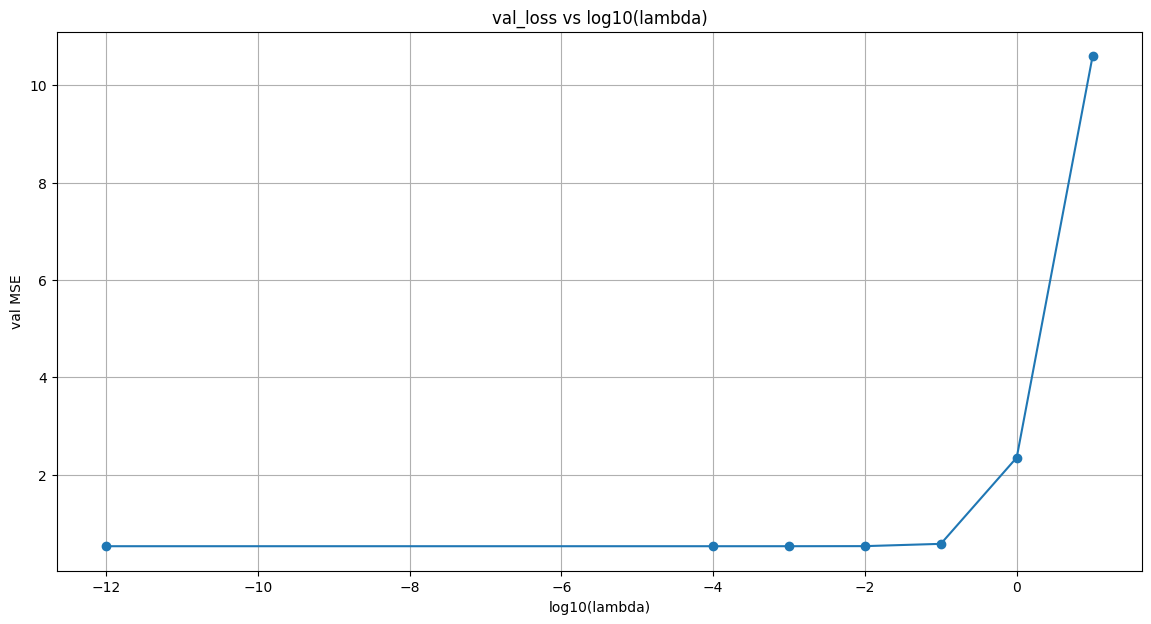

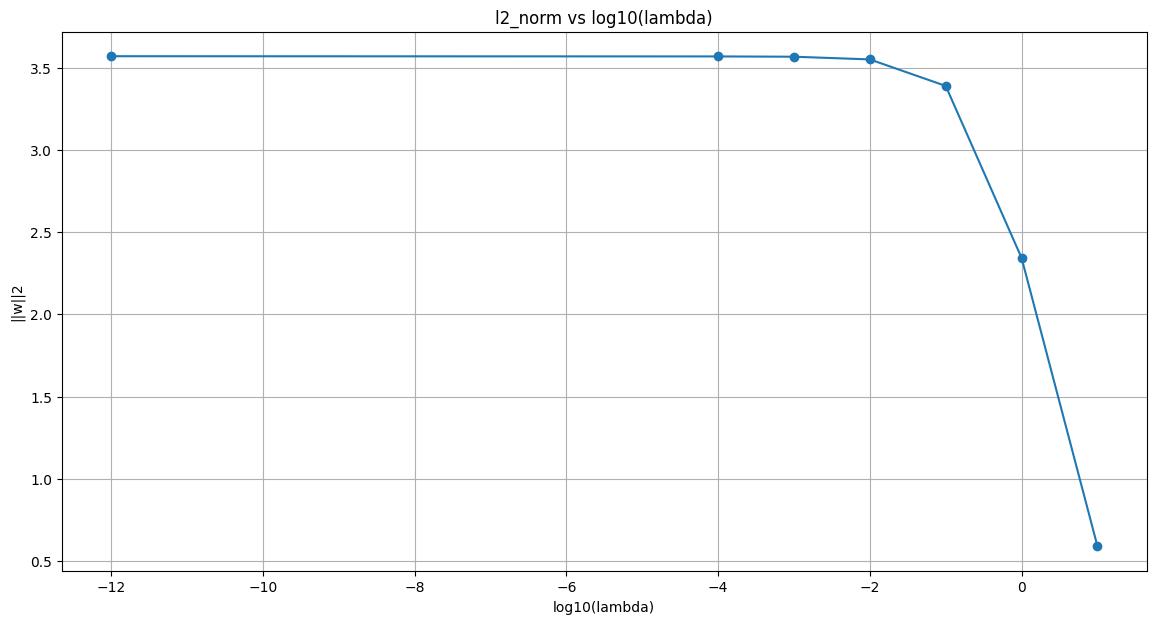

Наименьший val MSE: 0.5306
Результат получен при lambda: 0.0001


In [11]:
# Задача 6. Эксперимент с λ (для L2)

lambdas = [0.0, 1e-4, 1e-3, 1e-2, 1e-1, 1.0, 10.0] # можно выбрать свои
val_losses = []
test_losses = []
norms = []

for lam in lambdas:
# ваш код здесь
    _, w_l2, _, val_losses_lam, test_l2 = train_linear_with_l2(
        X_train, y_train, X_val, y_val, X_test, y_test,
        lam, lr=0.05, epochs=65
    )
    val_losses.append(val_losses_lam[-1])
    test_losses.append(test_l2)
    norms.append(float(torch.norm(w_l2).detach().item()))


# В качестве val MSE выводится лосс на валидационной выборке
# для последней эпохи обучения
for lam, v, n in zip(lambdas, val_losses, norms):
    print(f"λ={lam:<6} | val MSE={v:.4f} | ||w||2={n:.3f}")

# Графики зависимостей от log10(lambda)
# ваш код здесь
log_lambdas = [math.log10(x) for x in lambdas[1:]]
log_lambdas.insert(0, -12)

plt.figure(figsize=(14, 7))
plt.plot(
    log_lambdas, val_losses, marker='o'

)
plt.grid(True)
plt.title("val_loss vs log10(lambda)")
plt.xlabel("log10(lambda)"); plt.ylabel("val MSE")
plt.show()


plt.figure(figsize=(14, 7))
plt.plot(
    log_lambdas, norms, marker='o'

)
plt.grid(True)
plt.title("l2_norm vs log10(lambda)")
plt.xlabel("log10(lambda)"); plt.ylabel("||w||2")
plt.show()

print(f'Наименьший val MSE: {min(val_losses):.4f}')
print(f'Результат получен при lambda: {
    lambdas[val_losses.index(min(val_losses))]
}')


**Выводы:**  
1 Существенные различия val MSE при различных значениях $\lambda$ в данной задаче отсутствуют.  
2 Однако, наблюдается bias-variance tradeoff: наименьшим значениям val MSE соответствуют случаи, когда норма векторов весов имеет некоторое среднее значение (отличное от экстремального), т.е. когда модель, с одной стороны, не переобучена (максимальная норма), а, с другой стороны, не слишком упрощена (минимальная норма).

---

## Задача 7. Визуализация кривых обучения

### Постановка задачи

Необходимо обучить несколько вариантов одной и той же модели (например, без регуляризации, с L2 и с Early Stopping) и визуализировать кривые обучения: train loss и val loss по эпохам. На основе графиков нужно проанализировать, где начинается переобучение и как разные методы регуляризации его сдерживают.

### Теоретический минимум
- Кривая обучения: train/val loss как функция номера эпохи.
- Признак переобучения: train loss продолжает падать, а val loss начинает расти.
- Регуляризация (L2, Early Stopping) уменьшает разрыв между train и val, сглаживая кривые.

### Этапы решения
1. Реализуйте функцию обучения, которая в каждом запуске возвращает списки `train_losses` и `val_losses`.
2. Обучите минимум три варианта модели: без регуляризации, с L2 и с Early Stopping (используйте реализованный класс).
3. Постройте графики train/val loss по эпохам для каждого варианта (на одном графике или отдельными subplot’ами).
4. Для варианта с Early Stopping отметьте точку остановки.
5. Сформулируйте вывод: у какой модели наименьший разрыв и где видно переобучение.


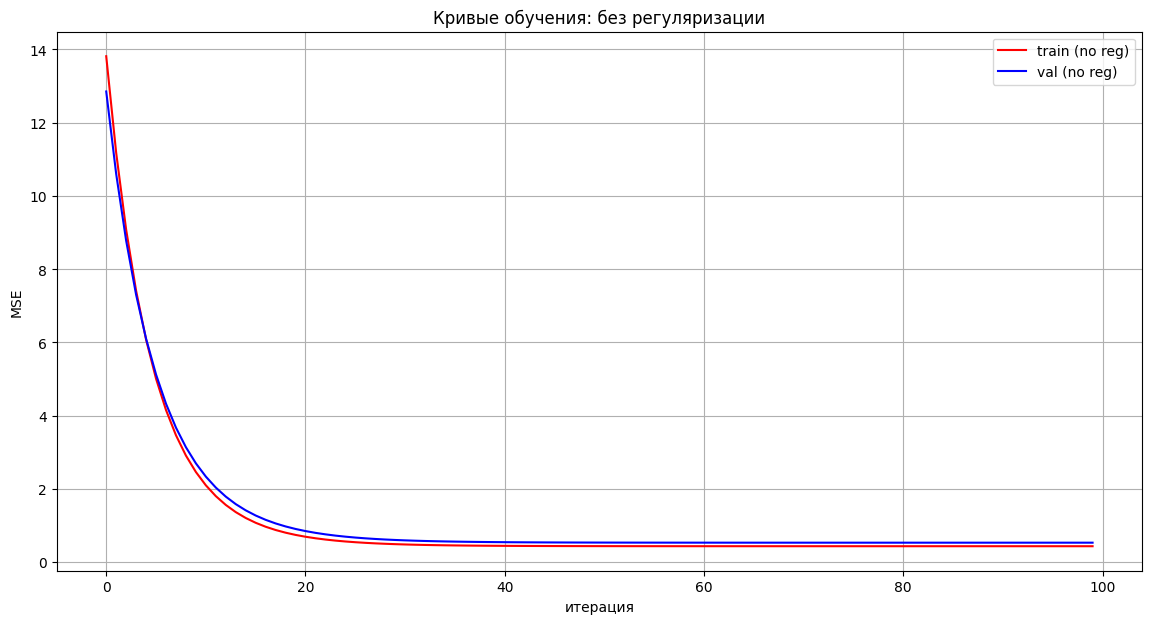

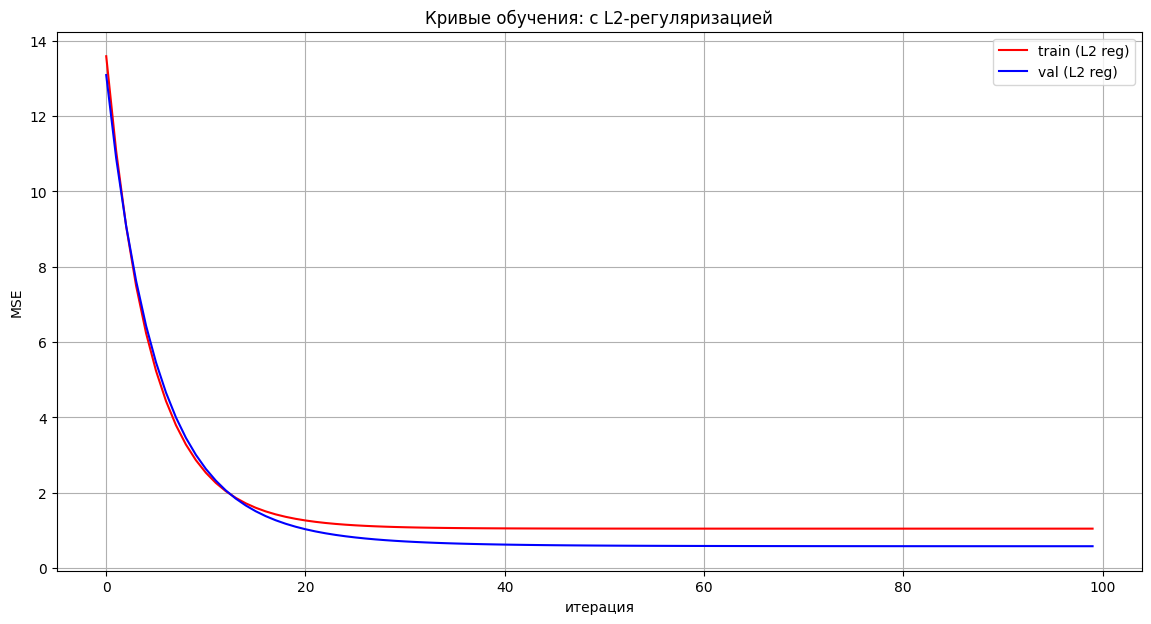

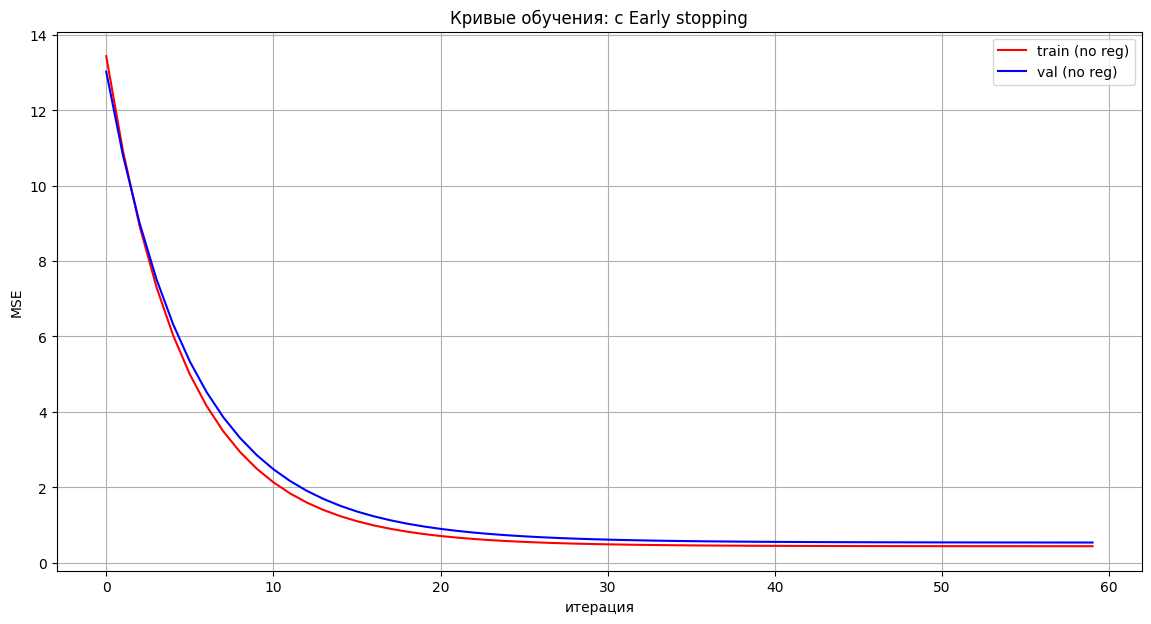

In [12]:
# Задача 7. Визуализация кривых обучения

# 1) Без регуляризации
# ваш код здесь
# т.е. когда max_epochs = patience
_, _, train_losses, val_losses, _ = train_linear_with_early_stopping(
    X_train, y_train, X_val, y_val, X_test, y_test,
    lr=0.05, max_epochs=100, patience=100
)

iterations = list(range(len(train_losses)))
plt.figure(figsize=(14, 7))
plt.plot(
    iterations, train_losses,
    color='red', label='train (no reg)'
)
plt.plot(
    iterations, val_losses,
    color='blue', label='val (no reg)'
)

plt.grid(True)
plt.legend()
plt.title("Кривые обучения: без регуляризации")
plt.xlabel("итерация"); plt.ylabel("MSE")
plt.show()


# 2) L2-регуляризация
# ваш код здесь
_, _, train_losses, val_losses, _ = train_linear_with_l2(
    X_train, y_train, X_val, y_val, X_test, y_test,
    lam=0.1, lr=0.05, epochs=100
)

iterations = list(range(len(train_losses)))
plt.figure(figsize=(14, 7))
plt.plot(
    iterations, train_losses,
    color='red', label='train (L2 reg)'
)
plt.plot(
    iterations, val_losses,
    color='blue', label='val (L2 reg)'
)

plt.grid(True)
plt.legend()
plt.title("Кривые обучения: с L2-регуляризацией")
plt.xlabel("итерация"); plt.ylabel("MSE")
plt.show()


# 3) Early stopping (без явного L2)
# ваш код здесь

_, _, train_losses, val_losses, _ = train_linear_with_early_stopping(
    X_train, y_train, X_val, y_val, X_test, y_test,
    lr=0.05, max_epochs=100, patience=3
)

iterations = list(range(len(train_losses)))
plt.figure(figsize=(14, 7))
plt.plot(
    iterations, train_losses,
    color='red', label='train (no reg)'
)
plt.plot(
    iterations, val_losses,
    color='blue', label='val (no reg)'
)

plt.grid(True)
plt.legend()
plt.title("Кривые обучения: с Early stopping")
plt.xlabel("итерация"); plt.ylabel("MSE")
plt.show()

# plt.figure()
# выведите три графика сранвнения кривых обучения на валидационной и тестовой выборках

**Выводы:**  
1 Наименьший разрыв между точностью при обучении и валидации наблюдается у моделей без регуляризации: без ранней остановки и с ранней остановкой.  
2 Ранняя остановка позволила при той же точности расчёта сократить количество эпох обучения.  
3 Переобучение наблюдается у модели с L2-регуляризацией: примерно после эпохи 30 test MSE продолжает немного снижаться, а val MSE уже принимает константное значение.

---

---
# ЗАДАЧИ ВЫСОКОЙ СЛОЖНОСТИ


**Цель:** понять, когда и почему использовать разные регуляризации.

---

## Задача 8. Monte Carlo Dropout

### Постановка задачи

Реализуйте функцию `mc_dropout_predict(model, X, n_samples)`, которая оценивает предсказания и неопределенность регрессионной нейросети с Dropout. Для этого нужно:
- выполнить `n_samples` прямых проходов модели в режиме `train()` (чтобы Dropout был активен);
- накапливать предсказания на одной и той же выборке `X`;
- вернуть среднее и стандартное отклонение предсказаний.

Примените метод к тестовым данным и визуализируйте средние предсказания и доверительный интервал.

### Теоретический минимум
- Dropout: при обучении случайно обнуляются выходы нейронов с вероятностью $p$, при инференсе используется масштабирование.
- Monte Carlo Dropout (Галь, Гхахрамани): оставляем Dropout включенным на инференсе и делаем многократные прогоны; дисперсия по семплам ≈ неопределенность модели.
- Для регрессии удобно визуализировать mean ± 2·std как приближенный доверительный интервал.

### Этапы решения
1. Определите MLP-модель с `nn.Dropout(p=...)` между слоями.
2. Реализуйте функцию `mc_dropout_predict(model, X, n_samples=100)`:
   - переведите модель в режим `train()`,
   - в цикле `for _ in range(n_samples)` собирайте предсказания `preds.append(model(X))` без backprop,
   - верните `mean = torch.mean(preds, dim=0)`, `std = torch.std(preds, dim=0)`.
3. Примените к test-данным, постройте график mean и интервала неопределенности.
4. Прокомментируйте, где модель наиболее/наименее уверена.


Shapes: torch.Size([600, 1]) torch.Size([600, 1])


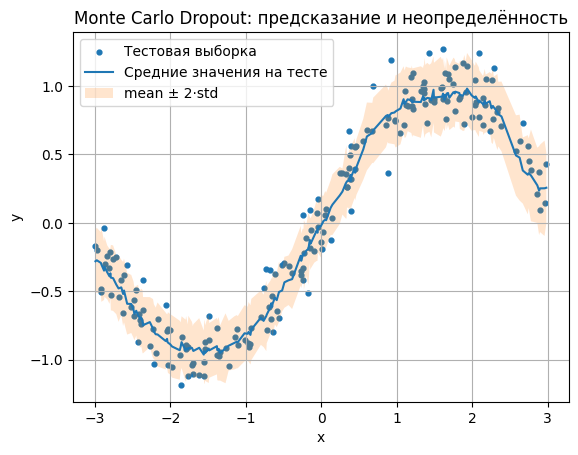

In [ ]:
# Задача 8. Monte Carlo Dropout

# Для наглядной визуализации сделаем 1D-регрессию (синус + шум)
def make_1d_regression(n=1000, noise=0.15):
    assert "ваш код здесь"
    x = np.linspace(-3, 3, n).astype(np.float32)
    np.random.seed(42)
    y = np.sin(x) + noise*np.random.randn(n).astype(np.float32)
    return x.reshape(-1, 1), y.reshape(-1, 1)


X1, y1 = make_1d_regression()
# ваш код здесь (сплит, преобразование в тензоры нужного формата)
(X1_train, y1_train), (X1_val, y1_val), (X1_test, y1_test) = train_val_test_split(X1, y1, 0.6, 0.2)

X1_train, y1_train = to_tensor(X1_train), to_tensor(y1_train).view(-1, 1)
X1_val, y1_val = to_tensor(X1_val), to_tensor(y1_val).view(-1, 1)
X1_test, y1_test = to_tensor(X1_test), to_tensor(y1_test).view(-1, 1)
print("Shapes:", X1_train.shape, y1_train.shape)


class MLPDropout(nn.Module):
    def __init__(self, p=0.2):
        assert "ваш код здесь"
        super().__init__()
        self.drop_net = nn.Sequential(
            nn.Linear(1, 32),
            nn.ReLU(),
            nn.Dropout(p=p),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Dropout(p=p),
            nn.Linear(64, 1)
        )

    def forward(self, x):
        assert "ваш код здесь"
        return self.drop_net(x)


def train_mlp(
        X_train_t: torch.Tensor,
        y_train_t: torch.Tensor,
        X_val_t: torch.Tensor,
        y_val_t: torch.Tensor,
        model, lr=0.001, epochs=1500
    ):
    assert "ваш код здесь"
    optimizer = optim.Adam(model.parameters(), lr=lr)
    best_value = float('inf')
    best_state = None
    for _ in range(epochs):
        model.train()
        optimizer.zero_grad()
        loss = mse(model(X_train_t), y_train_t)
        loss.backward()
        optimizer.step()

        model.eval()
        with torch.no_grad():
            cur_value = float(mse(model(X_val_t), y_val_t).item())
            if cur_value < best_value:
                best_value = cur_value
                best_state = {
                    key: value.detach().clone() for key, value in model.state_dict().items()
                }

    # Загрузка лучших весов в модель
    if best_state is not None:
        model.load_state_dict(best_state)
    return model


def mc_dropout_predict(model: nn.Module, X: torch.Tensor, n_samples: int = 50):
    """Возвращает mean и std предсказаний при включенном Dropout."""
    assert "ваш код здесь"
    # Работа с активным dropout
    model.train()
    y_pred_lst = []
    with torch.no_grad():
        for _ in range(n_samples):
            y_pred_lst.append(model(X).detach().cpu().numpy().ravel())
        y_pred_np = np.stack(y_pred_lst, axis=0)
        mean = y_pred_np.mean(axis=0)
        std = y_pred_np.std(axis=0)
    return mean, std



mlp = MLPDropout(p=0.25).to(device)
mlp = train_mlp(
    X1_train, y1_train,
    X1_val, y1_val,
    mlp
)

# Предсказания и неопределённость на плотной сетке
# ваш код здесь

X1_test_sorted, _ = torch.sort(X1_test.flatten())
X1_test_sorted = X1_test_sorted.reshape(X1_test_sorted.shape[0], 1)
mean_pred, std_pred = mc_dropout_predict(mlp, X1_test_sorted)

plt.figure()
# постройте красивый график
plt.scatter(
    X1_test.flatten().cpu(),
    y1_test.flatten().cpu(),
    s=12, label='Тестовая выборка'
)
plt.plot(
    X1_test_sorted.flatten().cpu(),
    mean_pred,
    label='Средние значения на тесте'
)
plt.fill_between(
    X1_test_sorted.flatten().cpu(),
    mean_pred - 2*std_pred,
    mean_pred + 2*std_pred,
    alpha=0.2,
    label='mean ± 2·std'
)
plt.title('Monte Carlo Dropout: предсказание и неопределённость')
plt.xlabel("x"); plt.ylabel("y")
plt.grid(True)
plt.legend()
plt.show()

**Выводы:**  
1 Из полученного графика следует, что модель наибелее "уверена" в предсказаниях на участках монотонного изменения функции и наимение "уверена" в предсказаниях вблизи экстремумов.

---

## Задача 9. Комплексное сравнение

### Постановка задачи

Сравните на одном и том же датасете несколько методов регуляризации:
1. Без регуляризации.
2. L2 (λ = 0.1).
3. L1 (λ = 0.1).
4. Elastic Net (смешение L1 и L2).
5. Early Stopping.

Для каждой модели вычислите:
- Test MSE;
- норму весов $\|w\|_2$;
- разреженность (долю весов, по модулю меньше 0.01).

Соберите результаты в таблицу и проанализируйте, какой метод дает лучший компромисс между качеством и сложностью модели.

### Теоретический минимум
- Elastic Net: $L = E(w) + \alpha \lambda \|w\|_1 + (1-\alpha) \lambda \|w\|_2^2/2$.
- Разные методы по-разному влияют на bias/variance и структуру весов (сильная L1 → сильно разреженные модели, L2/ES → более гладкие веса, Dropout → «шумная», но устойчиво обобщающая модель).
- Комплексное сравнение по нескольким метрикам позволяет понять, что важнее: точность, интерпретируемость или устойчивость.

### Этапы решения
1. Зафиксируйте один и тот же датасет и разбиение train/val/test.
2. Реализуйте обучение моделей для: NoReg, L2, L1, ElasticNet, Early Stopping (переиспользуя код предыдущих задач).
3. Для каждой модели посчитайте:
   - `test_mse`,
   - `l2_norm = torch.norm(w)`,
   - `sparsity = (torch.abs(w) < 0.01).float().mean()`.
4. Оформите результаты в Markdown-таблицу или DataFrame.
5. В выводе прокомментируйте, какой метод выглядит наиболее предпочтительным и почему (с точки зрения задачи и требований к модели).


In [13]:
# Задача 9. Комплексное сравнение

def train_linear_elastic_net(
    X_train_t: torch.Tensor,
    y_train_t: torch.Tensor,
    X_val_t: torch.Tensor,
    y_val_t: torch.Tensor,
    X_test_t: torch.Tensor,
    y_test_t: torch.Tensor,
    lam: float,
    alpha: float = 0.5,   # доля L1
    lr: float = 0.05,
    epochs: int = 900,
):
    assert "ваш код здесь"
    model_elast = LinearRegressor(X_train_t.shape[1]).to(device)
    model_elast.apply(reset_weights)
    optimizer = optim.SGD(model_elast.parameters(), lr=lr)

    train_losses, val_losses = [], []
    for epoch in range(epochs):
        model_elast.train()
        optimizer.zero_grad()
        y_pred_train = model_elast.forward(X_train_t.to(device))
        model_weights = model_elast.model_lin.weight.view(-1)
        loss = (
            mse(y_pred_train.flatten(), y_train_t.flatten().to(device))
            + alpha*compute_l1_regularization(model_weights, lam)
            + (1 - alpha)*compute_l2_regularization(model_weights, lam)
        )
        loss.backward()
        optimizer.step()

        model_elast.eval()
        with torch.no_grad():
            train_losses.append(float(loss.item()))
            val_losses.append(float(mse(model_elast(X_val_t.to(device)), y_val_t.to(device)).item()))

    with torch.no_grad():
        test_loss = float(mse(model_elast(X_test_t.to(device)), y_test_t.to(device)).item())
        w_hat = model_elast.model_lin.weight.detach().view(-1, 1).clone()

    return model_elast, w_hat, train_losses, val_losses, test_loss


result_dict = {
    'Regularization': ['None', 'L2', 'L1', 'Elastic Net', 'Early Stopping'],
    'test_mse': [],
    'l2_norm': [],
    'sparsity': []
}

# 1) Без регуляризации
# ваш код здесь
_, w_h, _, _, test_MSE = train_linear_with_early_stopping(
    X_train, y_train, X_val, y_val, X_test, y_test,
    lr=0.05, max_epochs=50, patience=50, min_delta=1e-4
)
result_dict['test_mse'].append(test_MSE)
result_dict['l2_norm'].append(float(torch.norm(w_h).detach().item()))
result_dict['sparsity'].append((torch.abs(w_h) < 0.01).float().mean().item())

lam = 0.1
# 2) L2 (λ=0.1)
# ваш код здесь
_, w_h, _, _, test_MSE = train_linear_with_l2(
    X_train, y_train, X_val, y_val, X_test, y_test,
    lam, lr=0.05, epochs=50
)
result_dict['test_mse'].append(test_MSE)
result_dict['l2_norm'].append(float(torch.norm(w_h).detach().item()))
result_dict['sparsity'].append((torch.abs(w_h) < 0.01).float().mean().item())

# 3) L1 (λ=0.1)
# ваш код здесь
_, w_h, _, _, test_MSE = train_linear_with_l1(
    X_train, y_train, X_val, y_val, X_test, y_test,
    lam, lr=0.05, epochs=50
)
result_dict['test_mse'].append(test_MSE)
result_dict['l2_norm'].append(float(torch.norm(w_h).detach().item()))
result_dict['sparsity'].append((torch.abs(w_h) < 0.01).float().mean().item())

# 4) Elastic Net (λ=0.1, alpha=0.5)
# ваш код здесь
_, w_h, _, _, test_MSE = train_linear_elastic_net(
    X_train, y_train, X_val, y_val, X_test, y_test,
    lam, lr=0.05, epochs=50
)
result_dict['test_mse'].append(test_MSE)
result_dict['l2_norm'].append(float(torch.norm(w_h).detach().item()))
result_dict['sparsity'].append((torch.abs(w_h) < 0.01).float().mean().item())

# 5) Early Stopping (без явного L2)
# ваш код здесь
_, w_h, _, _, test_MSE = train_linear_with_early_stopping(
    X_train, y_train, X_val, y_val, X_test, y_test,
    lr=0.05, max_epochs=50, patience=3, min_delta=1e-4
)
result_dict['test_mse'].append(test_MSE)
result_dict['l2_norm'].append(float(torch.norm(w_h).detach().item()))
result_dict['sparsity'].append((torch.abs(w_h) < 0.01).float().mean().item())


#def summarize(name, w, test_mse_value):
#    assert "ваш код здесь"

# Оформление результатов в DataFrame.
result_df = pd.DataFrame(result_dict)
display(result_df)

,Regularization,test_mse,l2_norm,sparsity
0,None,0.472810,3.539655,0.08
1,L2,0.540200,3.370623,0.08
2,L1,0.505691,3.459638,0.28
3,Elastic Net,0.519147,3.414276,0.16
4,Early Stopping,0.471985,3.537980,0.08


**Выводы:**  
1 Также, как и ранее в задании 5, для различных типов регуляризации получены схожие результаты по тестовому MSE и норме вектора весов.  
2 Результаты намерено выведены для малого числа эпох (50), т.к. при числе эпох более 100 результаты для моделей становятся неразличимыми.       
3 Как было отмечено ранее, схожие рузультаты при различных типах регуляризации могут объясняться простотой модели, состоящей из одного нейрона.

---